In [1]:
import numpy as np
import os
import pickle
import pandas as pd
from nilearn.image import load_img, new_img_like
from scipy.stats import pearsonr
from scipy.io import loadmat
from scipy.io import savemat
import seaborn as sns
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, surface
from nilearn.plotting import plot_surf_stat_map
def conv_r2z(r):
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))
def conv_z2r(z):
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)
# os.chdir('/Users/jinke/Desktop/SocialAha')

In [2]:
aha_dir = '/Users/jinke/Desktop/socialaha_github/socialaha_transcribe/ahascreenshots/'
subs = os.listdir(aha_dir)
subs.sort()
subs = subs[1:]

In [3]:
n_aha_allsubs = []
for sub in subs:
    n_aha_sub = 0
    for block in range(1,10+1):
        this_dir = aha_dir + sub + '/block' + str(block)
        n_aha_block = len(os.listdir(this_dir))
        n_aha_sub = n_aha_sub + n_aha_block
    n_aha_allsubs.append(n_aha_sub)

In [4]:
np.max(n_aha_allsubs)

182

In [5]:
np.std(n_aha_allsubs)

38.5253541007381

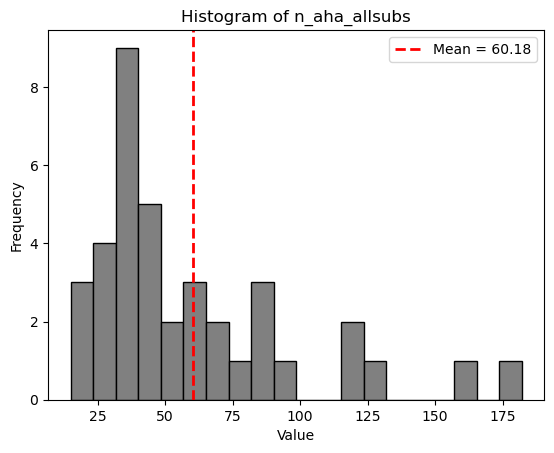

In [6]:
# Histogram with dark gray bars
plt.hist(n_aha_allsubs, bins=20, color='gray', edgecolor='black')

# Add mean line
mean_val = np.mean(n_aha_allsubs)
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean = {mean_val:.2f}')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of n_aha_allsubs')
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


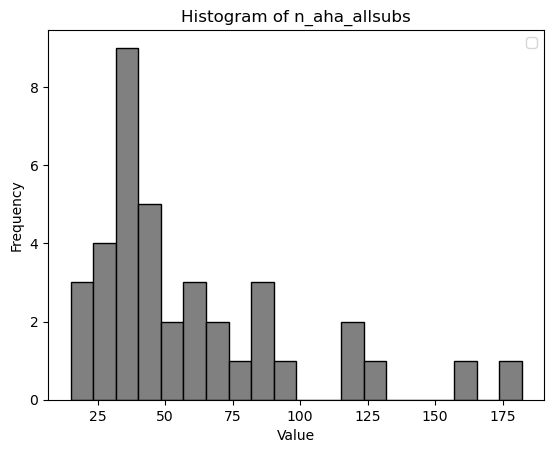

In [7]:
# Histogram with dark gray bars
plt.hist(n_aha_allsubs, bins=20, color='gray', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of n_aha_allsubs')
plt.legend()
plt.savefig("/Users/jinke/Desktop/histogram.png", dpi=600, bbox_inches='tight')
plt.show()

# Save figure at high resolution